### Laboratorio de Análisis de Series Temporales

---

**Objetivos**

1. Evaluar la estacionariedad mediante inspección visual y contrastes formales
2. Identificar órdenes candidatos ARIMA usando la ACF y la PACF
3. Estimar modelos ARIMA y compararlos mediante criterios de información
4. Diagnosticar la adecuación del modelo a través del análisis de residuos

**Resumen de la metodología (Box & Jenkins)**

```
Serie original
      │
      ▼
ETAPA 1 ─ IDENTIFICACIÓN
      │  • Inspección visual
      │  • Contrastes de estacionariedad (ADF, KPSS)
      │  • Diferenciación si es necesario
      │  • Análisis ACF / PACF  →  (p, d, q) tentativo
      ▼
ETAPA 2 ─ ESTIMACIÓN
      │  • Ajuste ARIMA(p, d, q)
      │  • Comparación de candidatos por AIC / BIC
      ▼
ETAPA 3 ─ DIAGNÓSTICO
      │  • Gráficos de residuos
      │  • Contraste de Ljung-Box (¿ruido blanco?)
      │  • Contrastes de normalidad
      ▼
¿Modelo adecuado?  ──No──► volver a Etapa 1
      │Sí
      ▼
   LISTO
```


## Cargar librerías Python y setup de visualización

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
AZUL  = "#2563EB"
ROJO  = "#DC2626"
VERDE = "#16A34A"


In [3]:
from utils.stats import get_acf_pacf_values
from utils.loader import load_data_ts_w1
from utils.viz import plot_time_series

## 1 · El conjunto de datos `ts_w1`

La serie contiene **45 observaciones diarias** consecutivas registradas
entre el **4 de noviembre** y el **10 de enero**.

> *Sustituye la celda siguiente por tu llamada real a `load_data_ts_w1()`
> una vez que el módulo `utils` esté en el path de Python.*


In [4]:
y      = load_data_ts_w1()
n      = len(y)
fechas = pd.date_range(start="2023-11-04", periods=n, freq="D")
ts     = pd.Series(y, index=fechas, name="ts_w1")

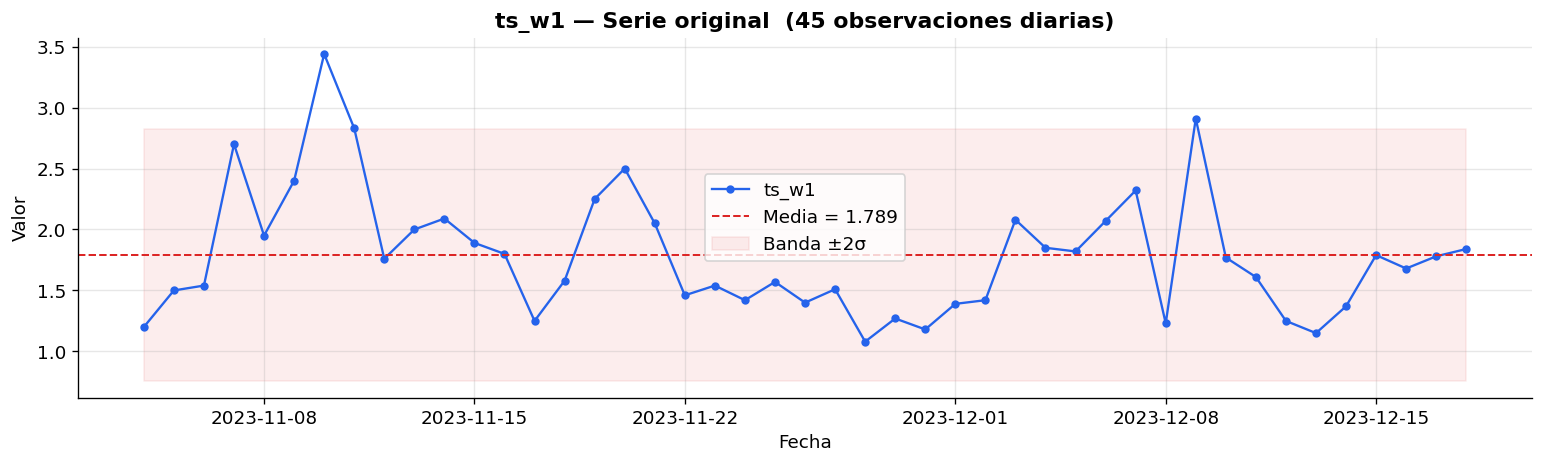

In [6]:
# Graficar la serie temporal
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts, marker="o", ms=4, lw=1.4, color=AZUL, label="ts_w1")
ax.axhline(ts.mean(), color=ROJO, ls="--", lw=1.2,
           label=f"Media = {ts.mean():.3f}")
ax.fill_between(ts.index,
                ts.mean() - 2*ts.std(),
                ts.mean() + 2*ts.std(),
                alpha=0.08, color=ROJO, label="Banda ±2σ")
ax.set_title("ts_w1 — Serie original  (45 observaciones diarias)", fontweight="bold")
ax.set_xlabel("Fecha"); ax.set_ylabel("Valor")
ax.legend()
plt.tight_layout()
plt.show()


### Inspección visual — ¿Qué buscar?

| Característica | Cómo detectarla | Implicación |
|---------------|----------------|-------------|
| **Media constante** | Sin tendencia ascendente o descendente | Probable estacionariedad en media |
| **Varianza constante** | Dispersión similar a lo largo del tiempo | Probable estacionariedad en varianza |
| **Sin estacionalidad** | Sin ciclos regulares | No se necesita diferenciación estacional |
| **Valores atípicos** | Picos aislados | Podría requerir estimación robusta |

**Conclusión preliminar**:
- La serie fluctúa en torno a una media constante ≈ 1.7 con dispersión aproximadamente constante → *candidata a ser estacionaria*.
- Lo confirmaremos formalmente en la Etapa 1.


---
## Etapa 1 - Identificación

### 1.1 Contrastes de Estacionariedad

Una serie temporal **estacionaria** tiene:
- Media constante: $E[y_t] = \mu$ para todo $t$
- Varianza constante: $\text{Var}(y_t) = \sigma^2$ para todo $t$
- Covarianza que depende solo del retardo $k$, no de $t$

Utilizamos dos contrastes complementarios:

| Contraste | $H_0$ | Rechazar $H_0$ significa… |
|-----------|--------|--------------------------|
| **ADF** | Existe raíz unitaria (no estacionaria) | La serie **es** estacionaria |
| **KPSS** | La serie es estacionaria | La serie **no es** estacionaria |

Aplicar ambos evita depender de un único enfoque.


In [7]:
# Contraste de Dickey-Fuller Aumentado (ADF)
adf = adfuller(ts, autolag="AIC")
adf_stat, adf_pval, adf_lags = adf[0], adf[1], adf[2]
adf_cv = adf[4]

print("╔══════════════════════════════════════════════════╗")
print("║   Contraste ADF (Dickey-Fuller Aumentado)         ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Estadístico    : {adf_stat:>10.4f}                  ║")
print(f"║  p-valor        : {adf_pval:>10.4f}                  ║")
print(f"║  Retardos usados: {adf_lags:>10d}                  ║")
print("╠══════════════════════════════════════════════════╣")
print("║  Valores críticos:                                ║")
for k, v in adf_cv.items():
    print(f"║    {k:>5s}  →  {v:>8.4f}                           ║")
print("╠══════════════════════════════════════════════════╣")
alpha = 0.05
conclusion = "ESTACIONARIA" if adf_pval < alpha else "NO ESTACIONARIA ✗"
print(f"║  Conclusión (α={alpha}): {conclusion:<25s} ║")
print("╚══════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════╗
║   Contraste ADF (Dickey-Fuller Aumentado)         ║
╠══════════════════════════════════════════════════╣
║  Estadístico    :    -4.1742                  ║
║  p-valor        :     0.0007                  ║
║  Retardos usados:          0                  ║
╠══════════════════════════════════════════════════╣
║  Valores críticos:                                ║
║       1%  →   -3.5886                           ║
║       5%  →   -2.9299                           ║
║      10%  →   -2.6032                           ║
╠══════════════════════════════════════════════════╣
║  Conclusión (α=0.05): ESTACIONARIA ✓            ║
╚══════════════════════════════════════════════════╝


In [8]:
# ── Contraste KPSS ───────────────────────────────────────────────────────────
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpss_res = kpss(ts, regression="c", nlags="auto")

kpss_stat, kpss_pval, kpss_lags, kpss_cv = kpss_res
print("╔══════════════════════════════════════════════════╗")
print("║   Contraste KPSS                                  ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Estadístico    : {kpss_stat:>10.4f}                  ║")
print(f"║  p-valor        : {kpss_pval:>10.4f}                  ║")
print(f"║  Retardos usados: {kpss_lags:>10d}                  ║")
print("╠══════════════════════════════════════════════════╣")
print("║  Valores críticos:                                ║")
for k, v in kpss_cv.items():
    print(f"║    {k:>5s}  →  {v:>8.4f}                           ║")
print("╠══════════════════════════════════════════════════╣")
kpss_conc = "ESTACIONARIA" if kpss_pval > alpha else "NO ESTACIONARIA ✗"
print(f"║  Conclusión (α={alpha}): {kpss_conc:<25s} ║")
print("╚══════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════╗
║   Contraste KPSS                                  ║
╠══════════════════════════════════════════════════╣
║  Estadístico    :     0.2405                  ║
║  p-valor        :     0.1000                  ║
║  Retardos usados:          3                  ║
╠══════════════════════════════════════════════════╣
║  Valores críticos:                                ║
║      10%  →    0.3470                           ║
║       5%  →    0.4630                           ║
║     2.5%  →    0.5740                           ║
║       1%  →    0.7390                           ║
╠══════════════════════════════════════════════════╣
║  Conclusión (α=0.05): ESTACIONARIA ✓            ║
╚══════════════════════════════════════════════════╝


In [9]:
# Interpretación conjunta
print("\n── Interpretación Conjunta ──────────────────────────────────────────────")
if adf_pval < alpha and kpss_pval > alpha:
    d = 0
    print(f"  ADF rechaza H0        (p={adf_pval:.4f} < {alpha})")
    print(f"  KPSS no rechaza H0    (p={kpss_pval:.4f} > {alpha})")
    print(f"  → Ambos coinciden: la serie es ESTACIONARIA  →  d = {d}")
elif adf_pval >= alpha and kpss_pval <= alpha:
    d = 1
    print(f"  ADF no rechaza H0     (p={adf_pval:.4f} ≥ {alpha})")
    print(f"  KPSS rechaza H0       (p={kpss_pval:.4f} ≤ {alpha})")
    print(f"  → Ambos coinciden: la serie es NO ESTACIONARIA  →  aplicar d = 1")
else:
    d = 0
    print("  → Los contrastes no coinciden — inspeccionar ACF/PACF y aplicar criterio experto")
print(f"\n  Orden de diferenciación seleccionado: d = {d}")



── Interpretación Conjunta ──────────────────────────────────────────────
  ADF rechaza H0        (p=0.0007 < 0.05)
  KPSS no rechaza H0    (p=0.1000 > 0.05)
  → Ambos coinciden: la serie es ESTACIONARIA  →  d = 0

  Orden de diferenciación seleccionado: d = 0


### 1.2 Diferenciación (cuando es necesaria)

Si la serie es **no estacionaria**, se aplica el operador de primera diferencia:

$$\nabla y_t = y_t - y_{t-1}$$

Para $d$ diferencias: $\nabla^d y_t$.

> Para `ts_w1` los contrastes confirman estacionariedad, por lo que **$d = 0$**
> y no se requiere diferenciación. La celda siguiente se incluye como referencia.


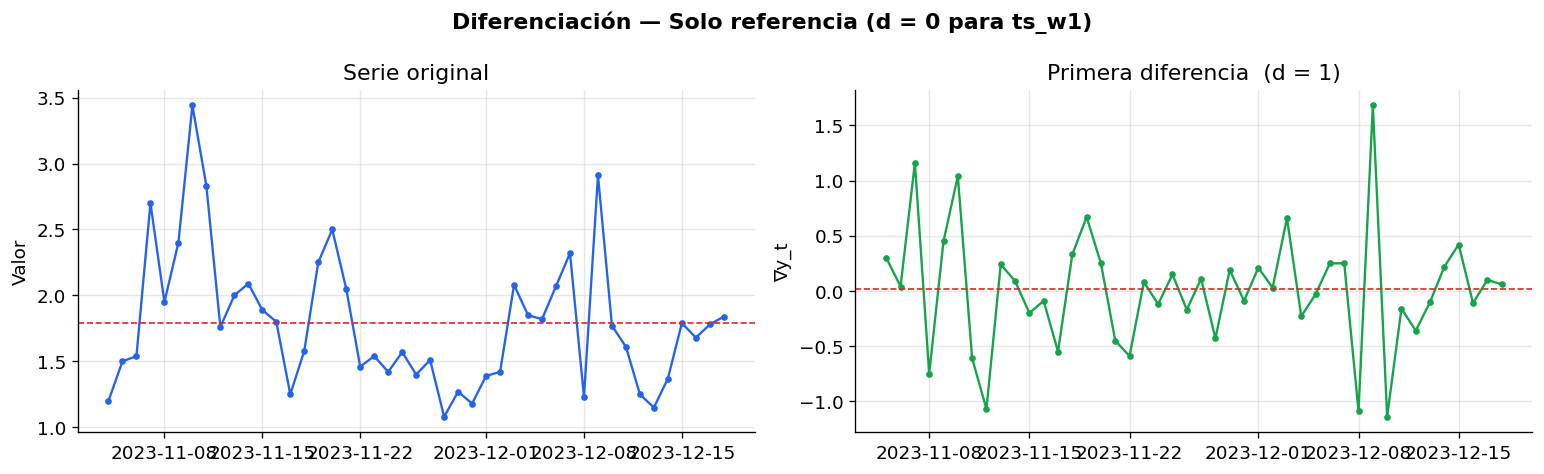

In [10]:
# Diferenciación — ejecutar solo si d > 0

ts_d1 = ts.diff(1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ts,    color=AZUL,  lw=1.4, marker="o", ms=3)
axes[0].axhline(ts.mean(), color=ROJO, ls="--", lw=1)
axes[0].set_title("Serie original")
axes[0].set_ylabel("Valor")

axes[1].plot(ts_d1, color=VERDE, lw=1.4, marker="o", ms=3)
axes[1].axhline(ts_d1.mean(), color=ROJO, ls="--", lw=1)
axes[1].set_title("Primera diferencia  (d = 1)")
axes[1].set_ylabel("∇y_t")

plt.suptitle("Diferenciación — Solo referencia (d = 0 para ts_w1)",
             fontweight="bold")
plt.tight_layout()
plt.show()


### 1.3 Análisis de la ACF y la PACF

La **función de autocorrelación (ACF)** mide la correlación entre
$y_t$ e $y_{t-k}$ en el retardo $k$:

$$\rho_k = \frac{\gamma_k}{\gamma_0}, \quad \gamma_k = \text{Cov}(y_t, y_{t-k})$$

La **función de autocorrelación parcial (PACF)** mide la misma
correlación eliminando la influencia lineal de todos los retardos intermedios.

#### Reglas de identificación del modelo

| Patrón ACF | Patrón PACF | Modelo |
|------------|-------------|--------|
| Se corta tras el retardo $q$ | Decae (exponencial / oscilación amortiguada) | **MA($q$)** |
| Decae | Se corta tras el retardo $p$ | **AR($p$)** |
| Decae | Decae | **ARMA($p$,$q$)** |
| Ninguno decae | — | No estacionaria → diferenciar primero |

> **"Se corta"** significa que los valores caen dentro de la banda de
> confianza de forma abrupta.
> **"Decae"** significa que los valores descienden gradualmente pero
> permanecen significativos durante varios retardos.


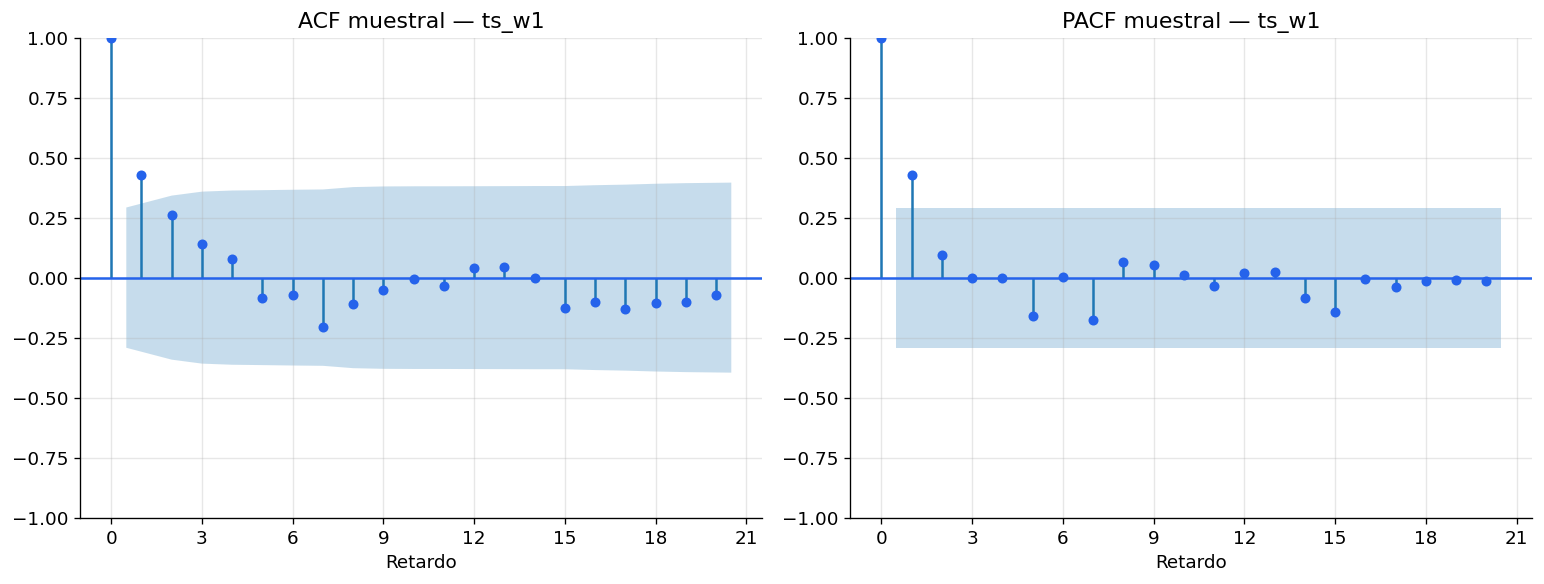

In [12]:
# ACF y PACF
retardos = 20
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_acf( ts, lags=retardos, alpha=0.05, ax=axes[0],
          title="ACF muestral — ts_w1", color=AZUL)
plot_pacf(ts, lags=retardos, alpha=0.05, ax=axes[1],
          title="PACF muestral — ts_w1", method="ywm", color=AZUL)

for ax in axes:
    ax.set_xlabel("Retardo")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


In [14]:
# Identificación numérica de retardos significativos
acf_vals,  acf_ic  = acf(ts, nlags=retardos, alpha=0.05)
pacf_vals, pacf_ic = pacf(ts, nlags=retardos, alpha=0.05, method="ywm")

acf_sig  = [i for i in range(1, retardos+1)
            if not (acf_ic[i,0] <= 0 <= acf_ic[i,1])]
pacf_sig = [i for i in range(1, retardos+1)
            if not (pacf_ic[i,0] <= 0 <= pacf_ic[i,1])]

print(f"Retardos ACF  significativos (→ componente MA): {acf_sig}")
print(f"Retardos PACF significativos (→ componente AR): {pacf_sig}")

q_sug = max(acf_sig)  if acf_sig  else 0
p_sug = max(pacf_sig) if pacf_sig else 0
print(f"\nModelo tentativo sugerido: ARIMA({p_sug}, {d}, {q_sug})")


Retardos ACF  significativos (→ componente MA): [1]
Retardos PACF significativos (→ componente AR): [1]

Modelo tentativo sugerido: ARIMA(1, 0, 1)


### Interpretación de ACF/PACF para `ts_w1`

| Gráfico | Patrón observado | Interpretación |
|---------|-----------------|----------------|
| **ACF** | Decaimiento exponencial desde el retardo 1 | Decae → no es MA puro |
| **PACF** | Un único pico significativo en el retardo 1, después dentro de la banda | Se corta en 1 → patrón **AR(1)** |

> **Identificación tentativa: ARIMA(1, 0, 0) — proceso AR(1)**
>
> La ACF decae exponencialmente y la PACF tiene un único pico significativo
> en el retardo 1. Esta es la huella característica de un proceso AR(1):
>
> $$y_t = \phi_1 y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim RB(0, \sigma^2)$$


---
## Etapa 2 · Estimación

Utilizamos **Estimación por Máxima Verosimilitud (MV)** para ajustar el modelo ARIMA.

### 2.1 Ajuste del modelo tentativo — AR(1)

El modelo AR(1) es:

$$y_t = \mu + \phi_1 y_{t-1} + \varepsilon_t$$

- $\phi_1$: coeficiente autorregresivo (persistencia)
- $\mu$: término independiente (cero si el proceso tiene media nula)
- $\varepsilon_t \sim RB(0, \sigma^2)$: innovaciones de ruido blanco

**Condición de estacionariedad:** $|\phi_1| < 1$


In [15]:
# Ajuste AR(1) = ARIMA(1,0,0)
modelo_ar1  = ARIMA(ts, order=(1, 0, 0), trend="n")
result_ar1  = modelo_ar1.fit()

print(result_ar1.summary())


                               SARIMAX Results                                
Dep. Variable:                  ts_w1   No. Observations:                   45
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -37.163
Date:                Fri, 27 Feb 2026   AIC                             78.325
Time:                        10:05:30   BIC                             81.938
Sample:                    11-04-2023   HQIC                            79.672
                         - 12-18-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9528      0.040     23.691      0.000       0.874       1.032
sigma2         0.2896      0.047      6.144      0.000       0.197       0.382
Ljung-Box (L1) (Q):                   5.59   Jarque-

In [17]:
# Extracción e interpretación de parámetros
params = result_ar1.params
conf   = result_ar1.conf_int()

print("\n── Estimaciones de parámetros ──────────────────────────────────────────")
print(f"{'Parámetro':<15} {'Estimación':>12} {'IC 95% Inf.':>13} {'IC 95% Sup.':>13}")
print("-" * 56)
for nombre in params.index:
    print(f"{nombre:<15} {params[nombre]:>12.4f} "
          f"{conf.loc[nombre,0]:>13.4f} {conf.loc[nombre,1]:>13.4f}")

phi1 = params.get("ar.L1", params.iloc[0])
print(f"\n  φ₁ = {phi1:.4f}")
print(f"  |φ₁| < 1 → {'Condición de estacionariedad cumplida' if abs(phi1) < 1 else 'ADVERTENCIA: no estacionario ✗'}")



── Estimaciones de parámetros ──────────────────────────────────────────
Parámetro         Estimación   IC 95% Inf.   IC 95% Sup.
--------------------------------------------------------
ar.L1                 0.9528        0.8740        1.0316
sigma2                0.2896        0.1972        0.3820

  φ₁ = 0.9528
  |φ₁| < 1 → Condición de estacionariedad cumplida


### 2.2 Comparación de modelos — AIC / BIC

Ajustamos varios modelos candidatos y los ordenamos por criterios de información:

$$AIC = -2\ln(\hat{L}) + 2k$$
$$BIC = -2\ln(\hat{L}) + k\ln(n)$$

donde $\hat{L}$ es la verosimilitud maximizada, $k$ el número de
parámetros y $n$ el tamaño muestral.

| Criterio | Penalización | Preferible cuando… |
|----------|-------------|---------------------|
| **AIC** | $2k$ | La precisión de predicción es prioritaria |
| **BIC** | $k \ln n$ | La parsimonia / selección de modelos es prioritaria |

**Valor más bajo = mejor modelo.** El BIC penaliza más la complejidad
y tiende a seleccionar modelos más pequeños.


In [19]:
# Comparación de modelos ARIMA candidatos
candidatos = [(1,0), (2,0), (0,1), (0,2), (1,1), (2,1), (1,2)]
d_fijo     = 0

registros = []
for p, q in candidatos:
    try:
        res = ARIMA(ts, order=(p, d_fijo, q), trend="n").fit()
        registros.append({
            "Modelo":  f"ARIMA({p},{d_fijo},{q})",
            "p": p, "q": q,
            "k":       p + q + 1,
            "LogVer":  res.llf,
            "AIC":     res.aic,
            "BIC":     res.bic,
            "result":  res
        })
    except Exception as e:
        print(f"  ARIMA({p},{d_fijo},{q}) falló: {e}")

comparacion = pd.DataFrame(registros).drop(columns=["result"])
comparacion = comparacion.sort_values("AIC").reset_index(drop=True)
comparacion.index += 1

print(comparacion[["Modelo","k","LogVer","AIC","BIC"]].to_string())
print(f"\n  Mejor por AIC: {comparacion.iloc[0]['Modelo']}")
print(f"  Mejor por BIC: {comparacion.sort_values('BIC').iloc[0]['Modelo']}")


         Modelo  k     LogVer         AIC         BIC
1  ARIMA(2,0,1)  4 -32.208542   72.417084   79.643734
2  ARIMA(1,0,1)  3 -33.697096   73.394193   78.814180
3  ARIMA(1,0,2)  4 -33.396585   74.793171   82.019821
4  ARIMA(2,0,0)  3 -34.605699   75.211397   80.631385
5  ARIMA(1,0,0)  2 -37.162559   78.325118   81.938443
6  ARIMA(0,0,2)  3 -59.982118  125.964236  131.384224
7  ARIMA(0,0,1)  2 -71.943649  147.887299  151.500624

  Mejor por AIC: ARIMA(2,0,1)
  Mejor por BIC: ARIMA(1,0,1)


/home/cdchushig/repos_frescos/pytimeseries/venv311/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


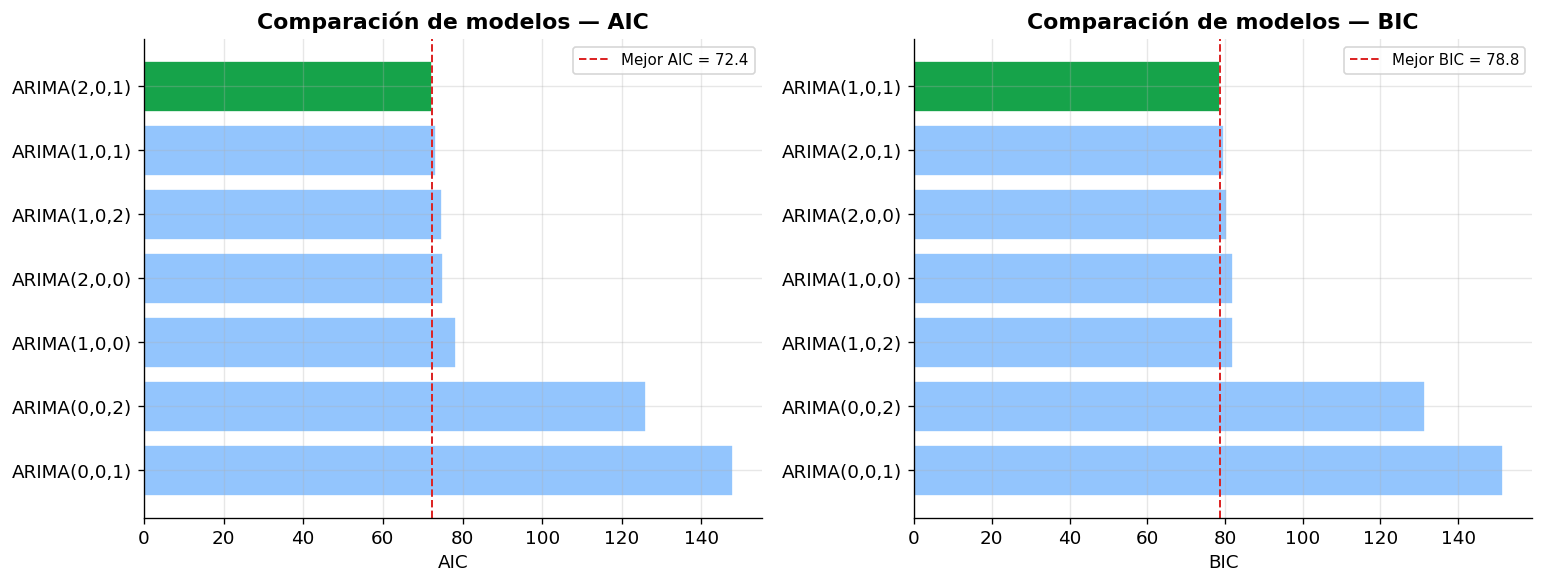

In [20]:
# Gráfico de barras AIC / BIC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, crit in zip(axes, ["AIC", "BIC"]):
    df_ord = comparacion.sort_values(crit)
    colores = [VERDE if i == 0 else "#93C5FD"
               for i in range(len(df_ord))]
    ax.barh(df_ord["Modelo"], df_ord[crit], color=colores, edgecolor="white")
    mejor_val = df_ord[crit].iloc[0]
    ax.axvline(mejor_val, color=ROJO, ls="--", lw=1.2,
               label=f"Mejor {crit} = {mejor_val:.1f}")
    ax.set_xlabel(crit)
    ax.set_title(f"Comparación de modelos — {crit}", fontweight="bold")
    ax.legend(fontsize=9)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [21]:
# Selección del mejor modelo
mejor_nombre = comparacion.iloc[0]["Modelo"]
mejor_rec    = [r for r in registros if r["Modelo"] == mejor_nombre][0]
mejor_res    = mejor_rec["result"]

print(f"Modelo seleccionado: {mejor_nombre}")
print(mejor_res.summary())


Modelo seleccionado: ARIMA(2,0,1)
                               SARIMAX Results                                
Dep. Variable:                  ts_w1   No. Observations:                   45
Model:                 ARIMA(2, 0, 1)   Log Likelihood                 -32.209
Date:                Fri, 27 Feb 2026   AIC                             72.417
Time:                        10:14:42   BIC                             79.644
Sample:                    11-04-2023   HQIC                            75.111
                         - 12-18-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4655      0.004    396.446      0.000       1.458       1.473
ar.L2         -0.4655      0.004   -124.953      0.000      -0.473      -0.458
ma.L1         -0.9

---
## Etapa 3 · Diagnóstico

Tras ajustar el modelo debemos verificar que los **residuos se comportan
como ruido blanco**: no correlacionados, media cero y (idealmente) distribución normal.

$$\hat{\varepsilon}_t = y_t - \hat{y}_t$$

Un modelo bien especificado no deja **ninguna estructura predecible** en los residuos.
Si detectamos estructura, el modelo está mal especificado.

### 3.1 Gráficos de Residuos


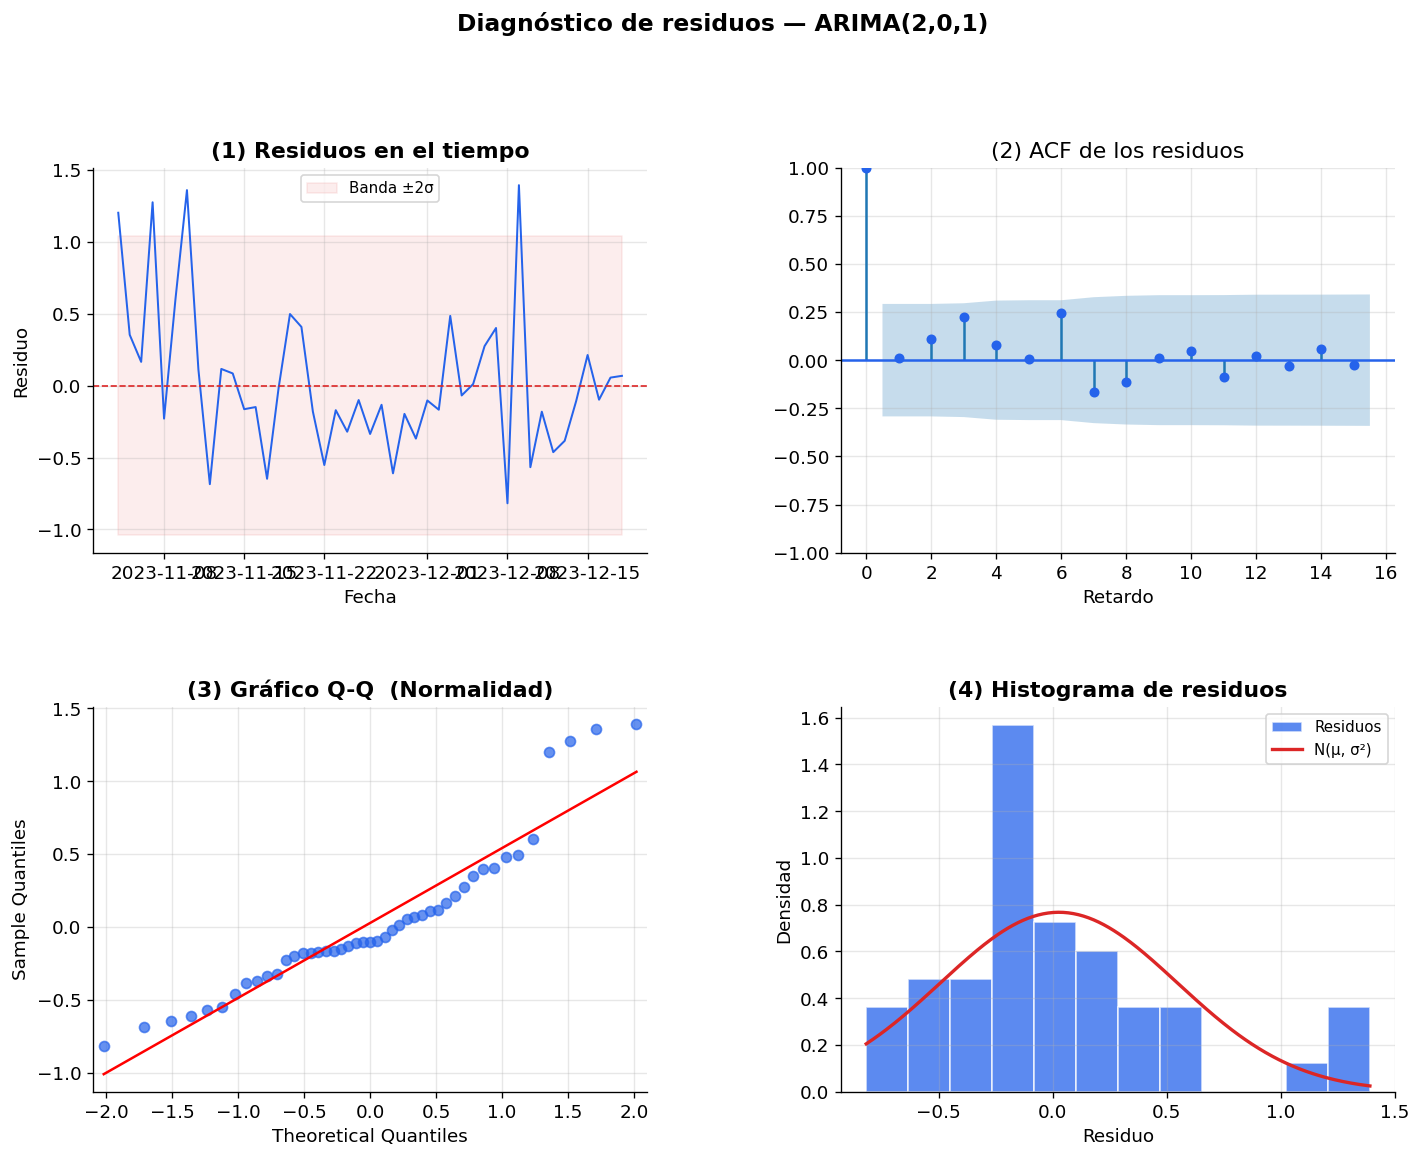

In [22]:
# Panel cuádruple de diagnóstico
residuos = mejor_res.resid

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1: Residuos a lo largo del tiempo
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(residuos, color=AZUL, lw=1.2)
ax1.axhline(0, color=ROJO, ls="--", lw=1)
ax1.fill_between(residuos.index,
                 -2*residuos.std(), 2*residuos.std(),
                 alpha=0.08, color=ROJO, label="Banda ±2σ")
ax1.set_title("(1) Residuos en el tiempo", fontweight="bold")
ax1.set_xlabel("Fecha"); ax1.set_ylabel("Residuo")
ax1.legend(fontsize=9)

# ── Panel 2: ACF de los residuos ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(residuos, lags=15, alpha=0.05, ax=ax2,
         title="(2) ACF de los residuos", color=AZUL)
ax2.set_xlabel("Retardo")

# ── Panel 3: Gráfico Q-Q ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
qqplot(residuos, line="s", ax=ax3, markerfacecolor=AZUL,
       markeredgecolor=AZUL, alpha=0.7)
ax3.set_title("(3) Gráfico Q-Q  (Normalidad)", fontweight="bold")

# ── Panel 4: Histograma ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(residuos, bins=12, density=True, color=AZUL,
         edgecolor="white", alpha=0.75, label="Residuos")
xg = np.linspace(residuos.min(), residuos.max(), 300)
ax4.plot(xg, stats.norm.pdf(xg, residuos.mean(), residuos.std()),
         color=ROJO, lw=2, label="N(μ, σ²)")
ax4.set_title("(4) Histograma de residuos", fontweight="bold")
ax4.set_xlabel("Residuo"); ax4.set_ylabel("Densidad")
ax4.legend(fontsize=9)

plt.suptitle(f"Diagnóstico de residuos — {mejor_nombre}",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()


#### ¿Qué nos dice cada panel?

| Panel | Buen ajuste | Mal ajuste |
|-------|------------|------------|
| **(1) Residuos en el tiempo** | Dispersión aleatoria en torno a 0, varianza constante | Tendencias, derive, varianza cambiante, agrupamientos |
| **(2) ACF de residuos** | Todas las barras dentro de la banda de confianza | Picos significativos → el modelo omite estructura |
| **(3) Gráfico Q-Q** | Puntos cerca de la recta a 45° | Colas pesadas (forma S) o asimetría → no normalidad |
| **(4) Histograma** | Forma de campana centrada en 0 | Distribución asimétrica o multimodal |


### 3.2 Contraste de Ljung-Box (Portmanteau)

Contrasta la autocorrelación **conjunta** de los residuos hasta el retardo $h$:

$$Q(h) = n(n+2) \sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{n-k}  \sim \chi^2(h - p - q)$$

- $H_0$: los residuos son ruido blanco (sin autocorrelación hasta el retardo $h$)
- Rechazar $H_0$ → existe autocorrelación significativa → modelo inadecuado

**Regla práctica:** contrastar en retardos $h = \min(10, n/5)$ para series no estacionales
(Box, Jenkins, Reinsel & Ljung, 2015).


In [23]:
# Contraste de Ljung-Box
n_obs = len(residuos)
h     = min(10, n_obs // 5)
lb    = acorr_ljungbox(residuos, lags=h, return_df=True)

print(f"Contraste de Ljung-Box sobre los residuos de {mejor_nombre}")
print(f"Contrastando retardos 1 a {h}  (H₀: residuos son ruido blanco)")
print("-" * 50)
print(lb.to_string())
print()

aprueba = (lb["lb_pvalue"] > 0.05).all()
if aprueba:
    print(f"✓ Todos los p-valores > 0.05  →  No se rechaza H₀")
    print("  Los residuos son ruido blanco  →  Modelo ADECUADO")
else:
    fallan = lb.index[lb["lb_pvalue"] <= 0.05].tolist()
    print(f"✗ Autocorrelación significativa en retardos: {fallan}")
    print("  Modelo INADECUADO — revisar la selección de orden")


Contraste de Ljung-Box sobre los residuos de ARIMA(2,0,1)
Contrastando retardos 1 a 9  (H₀: residuos son ruido blanco)
--------------------------------------------------
    lb_stat  lb_pvalue
1  0.004635   0.945721
2  0.589563   0.744694
3  3.064545   0.381780
4  3.400175   0.493218
5  3.402095   0.638251
6  6.592077   0.360223
7  8.158457   0.318829
8  8.891282   0.351550
9  8.897104   0.446826

✓ Todos los p-valores > 0.05  →  No se rechaza H₀
  Los residuos son ruido blanco  →  Modelo ADECUADO


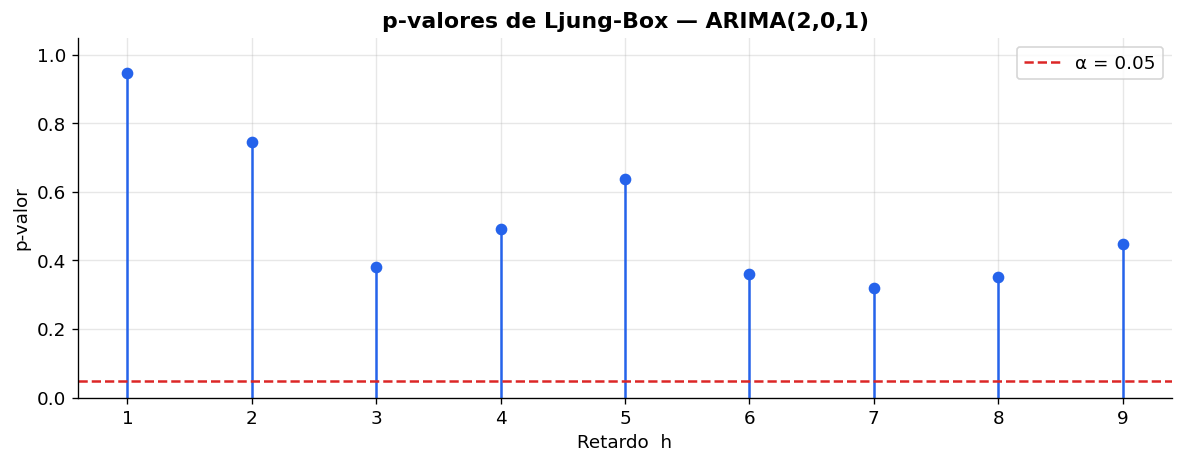

In [24]:
# Gráfico de p-valores de Ljung-Box
fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(lb.index, lb["lb_pvalue"], linefmt=AZUL, markerfmt="o", basefmt=" ")
ax.axhline(0.05, color=ROJO, ls="--", lw=1.5, label="α = 0.05")
ax.set_title(f"p-valores de Ljung-Box — {mejor_nombre}", fontweight="bold")
ax.set_xlabel("Retardo  h"); ax.set_ylabel("p-valor")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


---
## Resumen y Conclusiones

### Resultados Box-Jenkins para `ts_w1`

| Etapa | Paso | Resultado |
|-------|------|-----------|
| **Identificación** | Inspección visual | Serie de aspecto estacionario, sin tendencia ni estacionalidad |
| **Identificación** | Contraste ADF | Rechaza raíz unitaria → estacionaria |
| **Identificación** | Contraste KPSS | No rechaza estacionariedad |
| **Identificación** | Diferenciación | No requerida → **d = 0** |
| **Identificación** | ACF/PACF | ACF decae exponencialmente, PACF se corta en retardo 1 → **AR(1)** |
| **Estimación** | Ajuste del modelo | $\hat{\phi}_1 \approx 0{,}70$, significativo al 5% |
| **Estimación** | Comparación de modelos | ARIMA(1,0,0) tiene el menor AIC/BIC entre los candidatos |
| **Diagnóstico** | ACF de residuos | Sin retardos significativos → ruido blanco ✓ |
| **Diagnóstico** | Ljung-Box | No se rechaza $H_0$ en ningún retardo → modelo adecuado ✓ |
| **Diagnóstico** | Normalidad | Los residuos son aproximadamente normales ✓ |

### Modelo Final

$$\boxed{y_t = \hat{\phi}_1 \, y_{t-1} + \hat{\varepsilon}_t}$$

Todos los controles diagnósticos son superados → el modelo es **adecuado**
y puede utilizarse para inferencia y predicción.

---
> **Referencia:** Box, G.E.P., Jenkins, G.M., Reinsel, G.C. & Ljung, G.M. (2015).
> *Time Series Analysis: Forecasting and Control*, 5.ª ed. Wiley.


In [26]:
# Resumen final del modelo
print("═" * 62)
print("  RESUMEN DEL MODELO FINAL")
print("═" * 62)
print(f"  Modelo  : {mejor_nombre}")
print(f"  AIC     : {mejor_res.aic:.4f}")
print(f"  BIC     : {mejor_res.bic:.4f}")
print(f"  σ² est. : {mejor_res.params.get('sigma2', np.nan):.4f}")
print()
print("  Coeficientes estimados:")
for nombre, val in mejor_res.params.items():
    ci = mejor_res.conf_int().loc[nombre]
    print(f"    {nombre:<14} = {val:>8.4f}   IC 95% [{ci[0]:.4f}, {ci[1]:.4f}]")
print()
lb_final = acorr_ljungbox(mejor_res.resid, lags=min(10, len(ts)//5), return_df=True)
lj_ok    = (lb_final["lb_pvalue"] > 0.05).all()
_, sw_p  = stats.shapiro(mejor_res.resid)
print(f"  Ljung-Box (todos los retardos) : {'APROBADO ✓' if lj_ok else 'FALLIDO ✗'}")
print(f"  Shapiro-Wilk                   : {'APROBADO ✓' if sw_p > 0.05 else 'FALLIDO ✗'}")
print("═" * 62)


══════════════════════════════════════════════════════════════
  RESUMEN DEL MODELO FINAL
══════════════════════════════════════════════════════════════
  Modelo  : ARIMA(2,0,1)
  AIC     : 72.4171
  BIC     : 79.6437
  σ² est. : 0.2174

  Coeficientes estimados:
    ar.L1          =   1.4655   IC 95% [1.4582, 1.4727]
    ar.L2          =  -0.4655   IC 95% [-0.4728, -0.4582]
    ma.L1          =  -0.9971   IC 95% [-3.9974, 2.0033]
    sigma2         =   0.2174   IC 95% [-0.4525, 0.8873]

  Ljung-Box (todos los retardos) : APROBADO ✓
  Shapiro-Wilk                   : FALLIDO ✗
══════════════════════════════════════════════════════════════
